# Solar Site Finder — Data Science Analysis
**CS 210: Data Management for Data Science**  
New Jersey Solar Suitability Dashboard

This notebook walks through the full data science pipeline:
1. Exploratory Data Analysis (EDA) of the NJ candidate sites
2. Scoring methodology breakdown
3. ML model evaluation (Random Forest capacity predictor)
4. Candidate site bucket classification
5. County-level insights and validation against real NJ installations

In [2]:
import sqlite3
import pickle
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

PROJECT_ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
DB_PATH      = os.path.join(PROJECT_ROOT, 'database', 'solar_site_finder.db')
MODEL_PATH   = os.path.join(PROJECT_ROOT, 'models', 'solar_capacity_model.pkl')

plt.style.use('dark_background')
ORANGE = '#f97316'
YELLOW = '#eab308'
GREEN  = '#22c55e'
BLUE   = '#3b82f6'
PURPLE = '#a855f7'
COLORS = [ORANGE, YELLOW, GREEN, BLUE, PURPLE, '#ec4899', '#14b8a6', '#f43f5e']

print('Project root:', PROJECT_ROOT)
print('DB exists:', os.path.exists(DB_PATH))
print('Model exists:', os.path.exists(MODEL_PATH))

Project root: /Users/jayvora/Desktop/solar
DB exists: True
Model exists: True


In [3]:
conn = sqlite3.connect(DB_PATH)

candidates = pd.read_sql("""
    SELECT c.candidate_id, c.latitude, c.longitude, c.county,
           ss.total_score, ss.ghi_score, ss.land_cover_score,
           ss.slope_score, ss.proximity_score,
           ss.ghi_value, ss.land_cover_name, ss.slope_value,
           ss.rank, ss.predicted_capacity_mw
    FROM candidate_sites c
    JOIN site_scores ss ON c.candidate_id = ss.candidate_id
    WHERE c.state = 'NJ'
    ORDER BY ss.total_score DESC;
""", conn)

existing = pd.read_sql("""
    SELECT name, county, latitude, longitude,
           capacity_mw, area_acres, land_cover_type, install_year
    FROM existing_solar_sites
    WHERE state = 'NJ';
""", conn)

conn.close()

print(f'Candidate sites: {len(candidates):,}')
print(f'Existing NJ installations: {len(existing):,}')
candidates.head(3)

Candidate sites: 671
Existing NJ installations: 330


,candidate_id,latitude,longitude,county,total_score,ghi_score,land_cover_score,slope_score,proximity_score,ghi_value,land_cover_name,slope_value,rank,predicted_capacity_mw
0,422,39.32,-74.51,Atlantic,76.96,46.66,95.0,93.75,86.27,4.1666,Barren Land,1.25,1,34.16
1,18,39.62,-75.31,Salem,76.66,46.66,88.0,97.65,100.00,4.1666,Cultivated Crops,0.47,2,3.91
2,34,39.52,-75.21,Salem,76.44,46.66,88.0,96.60,99.86,4.1666,Cultivated Crops,0.68,3,129.47


---
## 1. Exploratory Data Analysis
### 1.1  Score Distribution

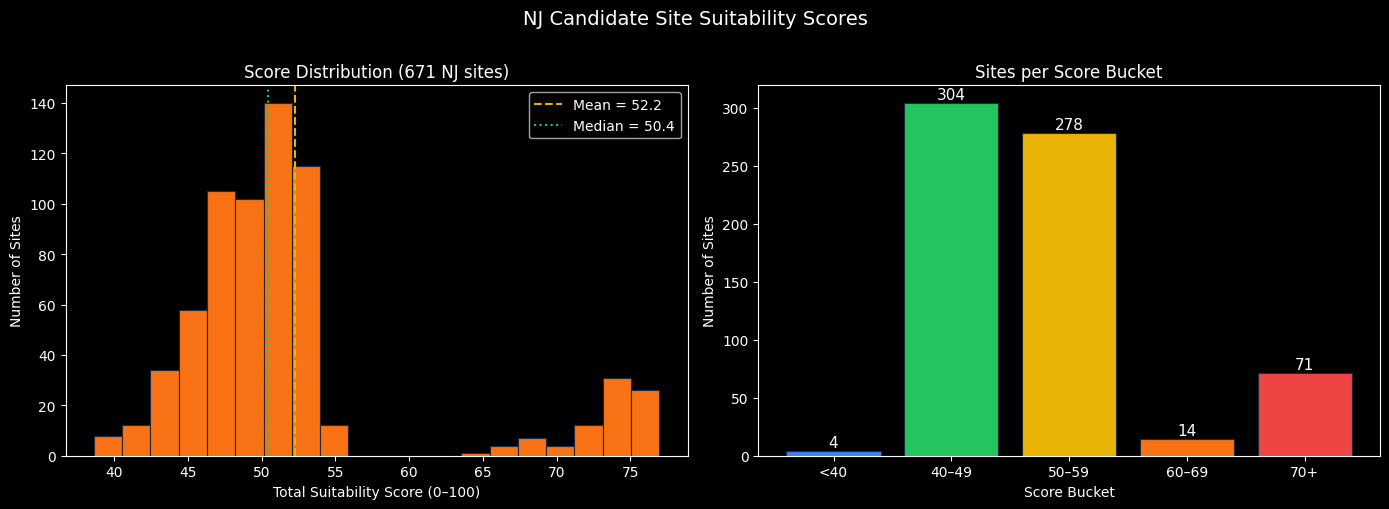

count    671.00
mean      52.24
std        8.65
min       38.62
25%       47.35
50%       50.41
75%       52.80
max       76.96
Name: total_score, dtype: float64


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('NJ Candidate Site Suitability Scores', fontsize=14, color='white', y=1.01)

ax = axes[0]
ax.hist(candidates['total_score'], bins=20, color=ORANGE, edgecolor='#1e293b', linewidth=0.8)
ax.axvline(candidates['total_score'].mean(), color=YELLOW, linestyle='--', linewidth=1.5,
           label=f'Mean = {candidates["total_score"].mean():.1f}')
ax.axvline(candidates['total_score'].median(), color=GREEN, linestyle=':', linewidth=1.5,
           label=f'Median = {candidates["total_score"].median():.1f}')
ax.set_xlabel('Total Suitability Score (0–100)')
ax.set_ylabel('Number of Sites')
ax.set_title('Score Distribution (671 NJ sites)')
ax.legend()

ax2 = axes[1]
buckets = pd.cut(candidates['total_score'],
                 bins=[0, 40, 50, 60, 70, 100],
                 labels=['<40', '40–49', '50–59', '60–69', '70+'])
bucket_counts = buckets.value_counts().sort_index()
bars = ax2.bar(bucket_counts.index, bucket_counts.values,
               color=[BLUE, GREEN, YELLOW, ORANGE, '#ef4444'],
               edgecolor='#1e293b', linewidth=0.8)
for bar, val in zip(bars, bucket_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(val), ha='center', va='bottom', fontsize=11, color='white')
ax2.set_xlabel('Score Bucket')
ax2.set_ylabel('Number of Sites')
ax2.set_title('Sites per Score Bucket')

plt.tight_layout()
plt.show()

print(candidates['total_score'].describe().round(2))

### 1.2  Individual Component Score Distributions

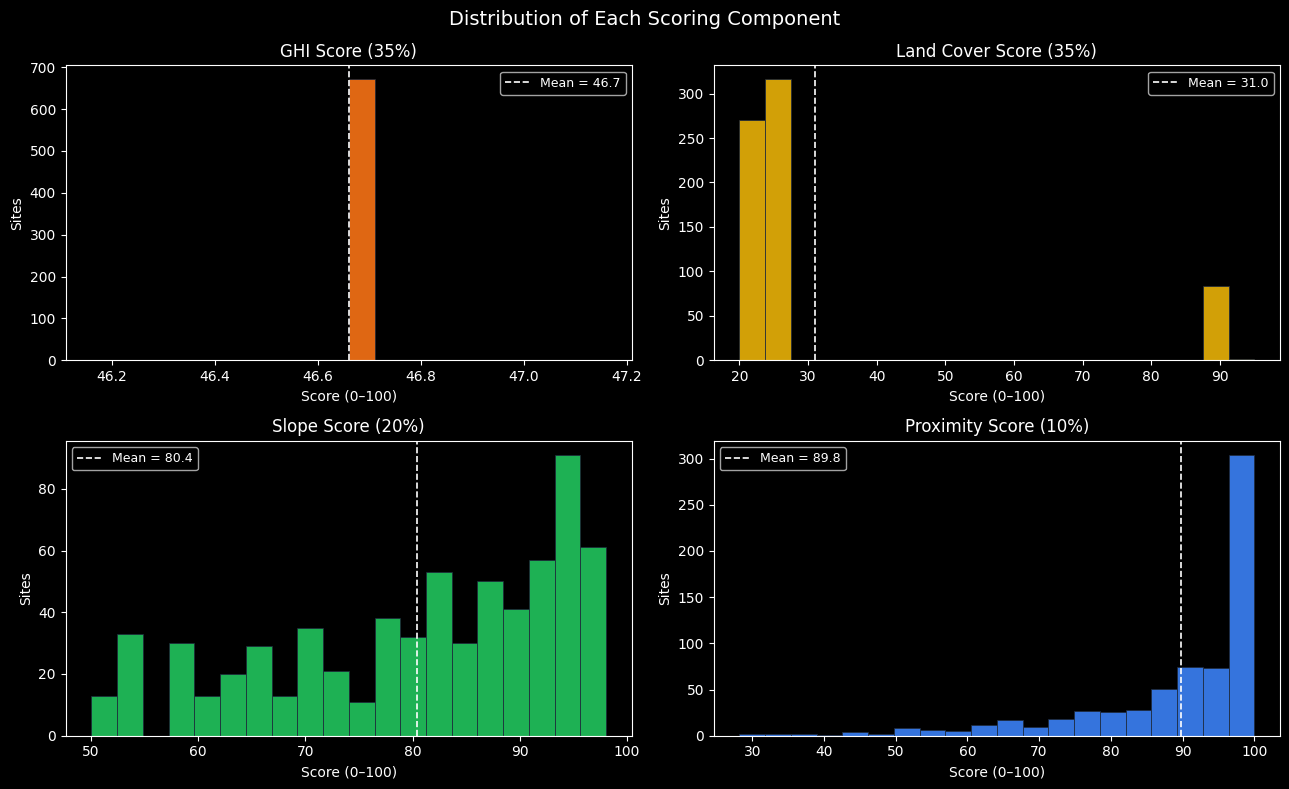

In [5]:
components = [
    ('ghi_score',        'GHI Score (35%)',        ORANGE),
    ('land_cover_score', 'Land Cover Score (35%)',  YELLOW),
    ('slope_score',      'Slope Score (20%)',       GREEN),
    ('proximity_score',  'Proximity Score (10%)',   BLUE),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('Distribution of Each Scoring Component', fontsize=14, color='white')

for (col, label, color), ax in zip(components, axes.flat):
    ax.hist(candidates[col], bins=20, color=color, edgecolor='#1e293b', linewidth=0.6, alpha=0.9)
    ax.axvline(candidates[col].mean(), color='white', linestyle='--', linewidth=1.2,
               label=f'Mean = {candidates[col].mean():.1f}')
    ax.set_title(label)
    ax.set_xlabel('Score (0–100)')
    ax.set_ylabel('Sites')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

### 1.3  Land Cover Breakdown

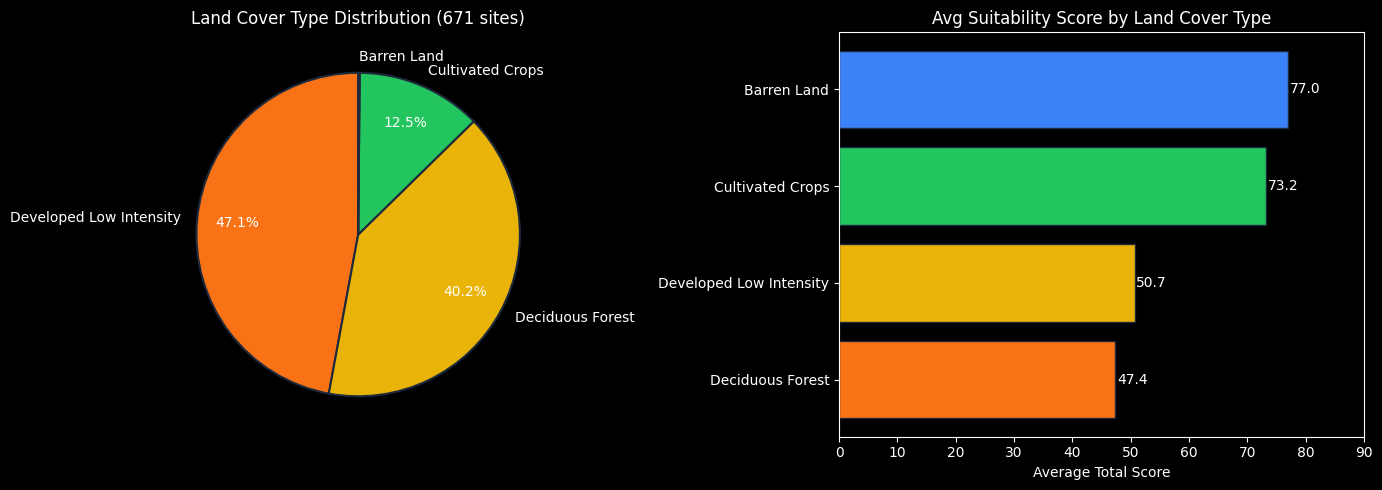


Land Cover Summary:
                         count  avg_score
land_cover_name                          
Barren Land                  1       77.0
Cultivated Crops            84       73.2
Deciduous Forest           270       47.4
Developed Low Intensity    316       50.7


In [6]:
lc_counts = candidates['land_cover_name'].value_counts()
lc_avg_score = candidates.groupby('land_cover_name')['total_score'].mean().round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
wedges, texts, autotexts = ax.pie(
    lc_counts.values, labels=lc_counts.index,
    autopct=lambda p: f'{p:.1f}%' if p > 1 else '',
    colors=COLORS[:len(lc_counts)],
    startangle=90, pctdistance=0.75,
    wedgeprops={'edgecolor': '#1e293b', 'linewidth': 1.5}
)
for t in texts: t.set_color('white')
for at in autotexts: at.set_color('white'); at.set_fontsize(10)
ax.set_title('Land Cover Type Distribution (671 sites)')

ax2 = axes[1]
sorted_lc = lc_avg_score.sort_values(ascending=True)
bars = ax2.barh(sorted_lc.index, sorted_lc.values,
                color=[COLORS[i % len(COLORS)] for i in range(len(sorted_lc))],
                edgecolor='#1e293b')
for bar, val in zip(bars, sorted_lc.values):
    ax2.text(val + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val}', va='center', fontsize=10)
ax2.set_xlabel('Average Total Score')
ax2.set_title('Avg Suitability Score by Land Cover Type')
ax2.set_xlim(0, 90)

plt.tight_layout()
plt.show()

print('\nLand Cover Summary:')
summary = pd.DataFrame({'count': lc_counts, 'avg_score': lc_avg_score})
print(summary.to_string())

### 1.4  County-Level Analysis

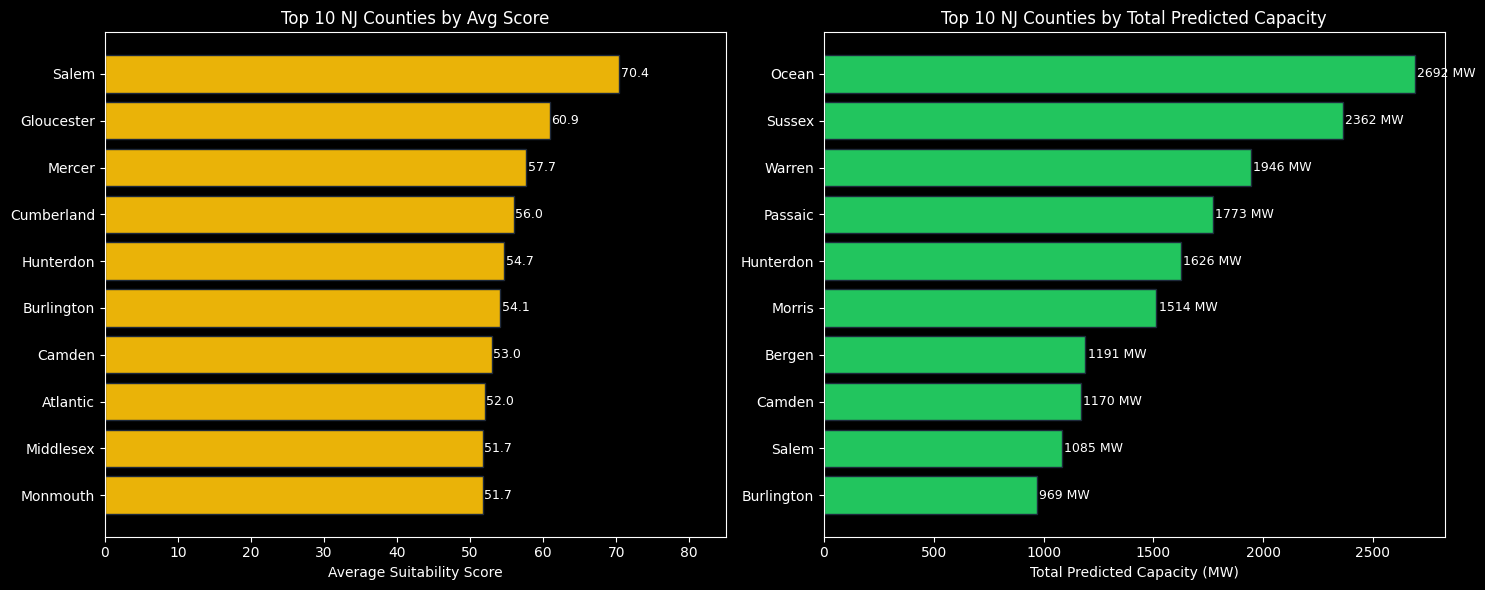


Full County Stats:
            site_count  avg_score  max_score  total_pred_mw  avg_pred_mw
county                                                                  
Salem               26       70.4       76.7         1085.2         41.7
Gloucester          29       60.9       76.4          678.4         23.4
Mercer              44       57.7       75.9          956.4         21.7
Cumberland          31       56.0       75.2          618.0         19.9
Hunterdon           40       54.7       74.9         1626.0         40.6
Burlington          45       54.1       75.6          969.0         21.5
Camden              40       53.0       74.9         1170.1         29.3
Atlantic            35       52.0       77.0          383.3         11.0
Middlesex           27       51.7       53.8          538.2         19.9
Monmouth            41       51.7       53.7          937.6         22.9
Hudson               8       50.9       51.6          343.8         43.0
Somerset            36       50

In [7]:
county_stats = candidates.groupby('county').agg(
    site_count    = ('candidate_id', 'count'),
    avg_score     = ('total_score', 'mean'),
    max_score     = ('total_score', 'max'),
    total_pred_mw = ('predicted_capacity_mw', 'sum'),
    avg_pred_mw   = ('predicted_capacity_mw', 'mean'),
).round(1).sort_values('avg_score', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
top10 = county_stats.head(10)
bars = ax.barh(top10.index[::-1], top10['avg_score'][::-1],
               color=YELLOW, edgecolor='#1e293b')
for bar, val in zip(bars, top10['avg_score'][::-1]):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val}', va='center', fontsize=9, color='white')
ax.set_xlabel('Average Suitability Score')
ax.set_title('Top 10 NJ Counties by Avg Score')
ax.set_xlim(0, 85)

ax2 = axes[1]
top10_mw = county_stats.sort_values('total_pred_mw', ascending=False).head(10)
bars2 = ax2.barh(top10_mw.index[::-1], top10_mw['total_pred_mw'][::-1],
                 color=GREEN, edgecolor='#1e293b')
for bar, val in zip(bars2, top10_mw['total_pred_mw'][::-1]):
    ax2.text(val + 10, bar.get_y() + bar.get_height()/2,
             f'{val:.0f} MW', va='center', fontsize=9, color='white')
ax2.set_xlabel('Total Predicted Capacity (MW)')
ax2.set_title('Top 10 NJ Counties by Total Predicted Capacity')

plt.tight_layout()
plt.show()

print('\nFull County Stats:')
print(county_stats.to_string())

---
## 2. Scoring Methodology Walkthrough
### 2.1  Weight Contribution to Final Score

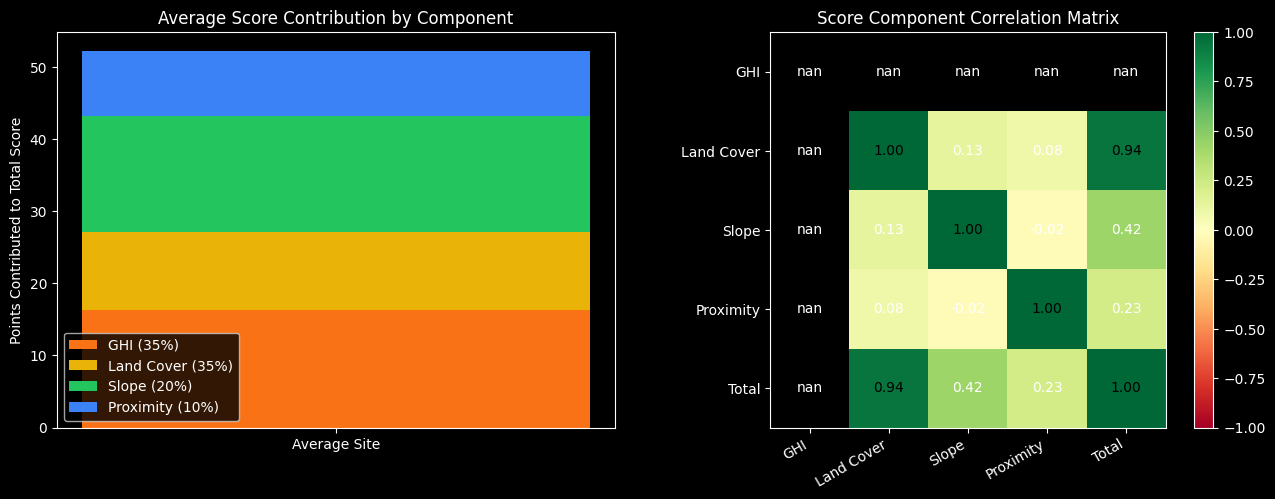

Average contribution to total score:
  GHI (35%): 16.33 pts  (31.3% of avg total)
  Land Cover (35%): 10.84 pts  (20.8% of avg total)
  Slope (20%): 16.09 pts  (30.8% of avg total)
  Proximity (10%): 8.98 pts  (17.2% of avg total)


In [8]:
WEIGHTS = {'ghi_score': 0.35, 'land_cover_score': 0.35, 'slope_score': 0.20, 'proximity_score': 0.10}

candidates['ghi_contrib']   = candidates['ghi_score']        * WEIGHTS['ghi_score']
candidates['lc_contrib']    = candidates['land_cover_score'] * WEIGHTS['land_cover_score']
candidates['slope_contrib'] = candidates['slope_score']      * WEIGHTS['slope_score']
candidates['prox_contrib']  = candidates['proximity_score']  * WEIGHTS['proximity_score']

contrib_means = {
    'GHI (35%)':      candidates['ghi_contrib'].mean(),
    'Land Cover (35%)': candidates['lc_contrib'].mean(),
    'Slope (20%)':    candidates['slope_contrib'].mean(),
    'Proximity (10%)': candidates['prox_contrib'].mean(),
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.bar(['Average Site'], [contrib_means['GHI (35%)']],
       color=ORANGE, label='GHI (35%)')
ax.bar(['Average Site'], [contrib_means['Land Cover (35%)']],
       bottom=[contrib_means['GHI (35%)']],
       color=YELLOW, label='Land Cover (35%)')
ax.bar(['Average Site'], [contrib_means['Slope (20%)']],
       bottom=[contrib_means['GHI (35%)'] + contrib_means['Land Cover (35%)']],
       color=GREEN, label='Slope (20%)')
ax.bar(['Average Site'], [contrib_means['Proximity (10%)']],
       bottom=[sum(list(contrib_means.values())[:3])],
       color=BLUE, label='Proximity (10%)')
ax.set_ylabel('Points Contributed to Total Score')
ax.set_title('Average Score Contribution by Component')
ax.legend()

ax2 = axes[1]
corr_cols = ['ghi_score', 'land_cover_score', 'slope_score', 'proximity_score', 'total_score']
corr = candidates[corr_cols].corr()
labels = ['GHI', 'Land Cover', 'Slope', 'Proximity', 'Total']
im = ax2.imshow(corr.values, cmap='RdYlGn', vmin=-1, vmax=1)
ax2.set_xticks(range(len(labels))); ax2.set_xticklabels(labels, rotation=30, ha='right')
ax2.set_yticks(range(len(labels))); ax2.set_yticklabels(labels)
for i in range(len(labels)):
    for j in range(len(labels)):
        ax2.text(j, i, f'{corr.values[i, j]:.2f}', ha='center', va='center',
                 fontsize=10, color='black' if abs(corr.values[i, j]) > 0.5 else 'white')
ax2.set_title('Score Component Correlation Matrix')
plt.colorbar(im, ax=ax2)

plt.tight_layout()
plt.show()

print('Average contribution to total score:')
for k, v in contrib_means.items():
    print(f'  {k}: {v:.2f} pts  ({v/candidates["total_score"].mean()*100:.1f}% of avg total)')

### 2.2  Step-by-Step Scoring Example — Top vs Bottom Site

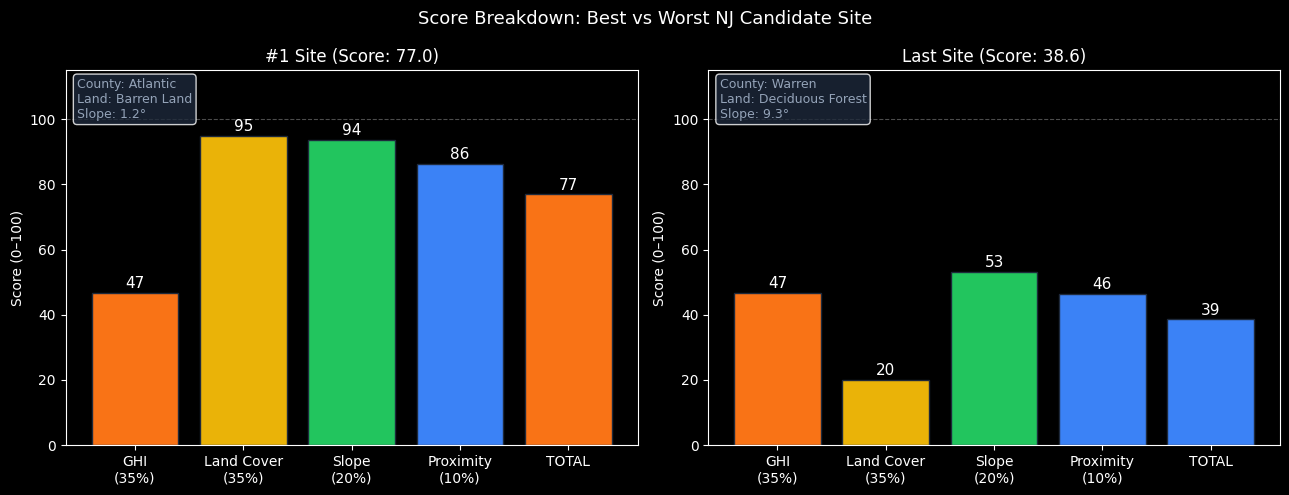

In [9]:
top_site    = candidates.iloc[0]
bottom_site = candidates.iloc[-1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

component_labels = ['GHI\n(35%)', 'Land Cover\n(35%)', 'Slope\n(20%)', 'Proximity\n(10%)', 'TOTAL']

for ax, site, title, color in [
    (axes[0], top_site,    f'#1 Site (Score: {top_site["total_score"]:.1f})', ORANGE),
    (axes[1], bottom_site, f'Last Site (Score: {bottom_site["total_score"]:.1f})', BLUE),
]:
    values = [
        site['ghi_score'],
        site['land_cover_score'],
        site['slope_score'],
        site['proximity_score'],
        site['total_score'],
    ]
    bars = ax.bar(component_labels, values,
                  color=[ORANGE, YELLOW, GREEN, BLUE, color],
                  edgecolor='#1e293b')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.0f}', ha='center', va='bottom', fontsize=11)
    ax.set_ylim(0, 115)
    ax.set_ylabel('Score (0–100)')
    ax.set_title(title)
    ax.axhline(100, color='white', linestyle='--', alpha=0.3, linewidth=0.8)
    info = f'County: {site["county"]}\nLand: {site["land_cover_name"]}\nSlope: {site["slope_value"]:.1f}°'
    ax.text(0.02, 0.98, info, transform=ax.transAxes, va='top', fontsize=9,
            color='#94a3b8', bbox=dict(boxstyle='round', facecolor='#1e293b', alpha=0.8))

plt.suptitle('Score Breakdown: Best vs Worst NJ Candidate Site', fontsize=13)
plt.tight_layout()
plt.show()

---
## 3. ML Model Evaluation
### 3.1  Model Performance Metrics

In [10]:
with open(MODEL_PATH, 'rb') as f:
    payload = pickle.load(f)

model       = payload['model']
metrics     = payload['metrics']
importances = payload['importances']
feat_cols   = payload['feature_cols']

print('=' * 50)
print('  Random Forest Capacity Prediction Model')
print('=' * 50)
print(f"  R²  (test set):           {metrics['r2']:.4f}  ({metrics['r2']*100:.1f}% variance explained)")
print(f"  RMSE:                     {metrics['rmse_mw']:.2f} MW")
print(f"  MAE:                      {metrics['mae_mw']:.2f} MW")
print(f"  Cross-val R² (5-fold):    {metrics['cv_r2_mean']:.4f} ± {metrics['cv_r2_std']:.4f}")
print(f"  Training rows:            {metrics['train_rows']:,}")
print(f"  Test rows:                {metrics['test_rows']:,}")
print('=' * 50)
print(f"\n  Target accuracy threshold: 80%  →  {'✓ MET' if metrics['r2'] >= 0.80 else '✗ NOT MET'}  (R²={metrics['r2']:.4f})")

  Random Forest Capacity Prediction Model
  R²  (test set):           0.9092  (90.9% variance explained)
  RMSE:                     11.41 MW
  MAE:                      3.94 MW
  Cross-val R² (5-fold):    0.8997 ± 0.0208
  Training rows:            5,583
  Test rows:                986

  Target accuracy threshold: 80%  →  ✓ MET  (R²=0.9092)


### 3.2  Feature Importance

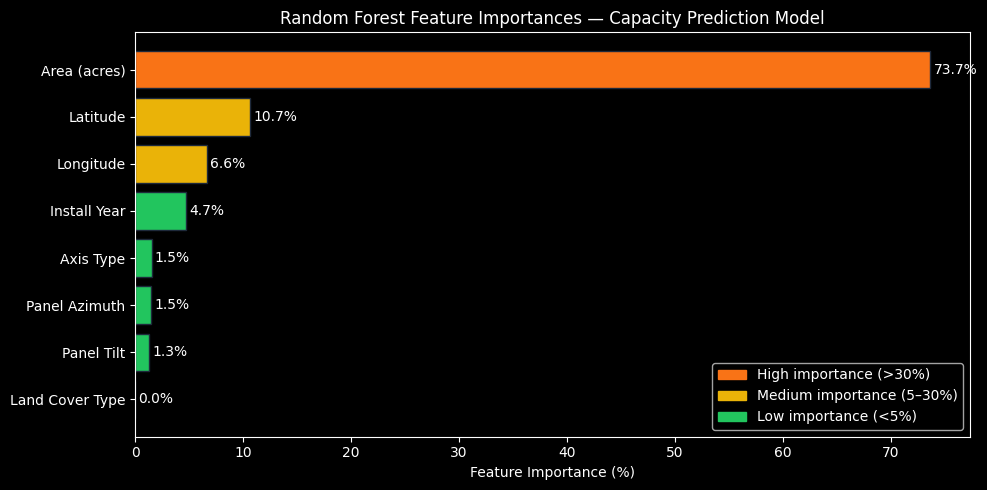


Key insight: 'Area' alone explains 73.7% of the model's decisions.
This makes physical sense — larger land parcels can fit more solar panels.


In [11]:
feat_labels = {
    'area_acres':    'Area (acres)',
    'latitude':      'Latitude',
    'longitude':     'Longitude',
    'azimuth':       'Panel Azimuth',
    'tilt':          'Panel Tilt',
    'axis_encoded':  'Axis Type',
    'land_encoded':  'Land Cover Type',
    'install_year':  'Install Year',
}

imp_series = pd.Series(importances).sort_values(ascending=True)
renamed    = imp_series.rename(index=feat_labels)

fig, ax = plt.subplots(figsize=(10, 5))
colors_imp = [ORANGE if v > 0.3 else (YELLOW if v > 0.05 else GREEN) for v in renamed.values]
bars = ax.barh(renamed.index, renamed.values * 100, color=colors_imp, edgecolor='#1e293b')
for bar, val in zip(bars, renamed.values):
    ax.text(val * 100 + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val*100:.1f}%', va='center', fontsize=10, color='white')
ax.set_xlabel('Feature Importance (%)')
ax.set_title('Random Forest Feature Importances — Capacity Prediction Model')

legend_patches = [
    mpatches.Patch(color=ORANGE, label='High importance (>30%)'),
    mpatches.Patch(color=YELLOW, label='Medium importance (5–30%)'),
    mpatches.Patch(color=GREEN,  label='Low importance (<5%)'),
]
ax.legend(handles=legend_patches, loc='lower right')
plt.tight_layout()
plt.show()

print(f"\nKey insight: 'Area' alone explains {importances['area_acres']*100:.1f}% of the model's decisions.")
print("This makes physical sense — larger land parcels can fit more solar panels.")

### 3.3  Actual vs Predicted on Training Data (USPVDB)

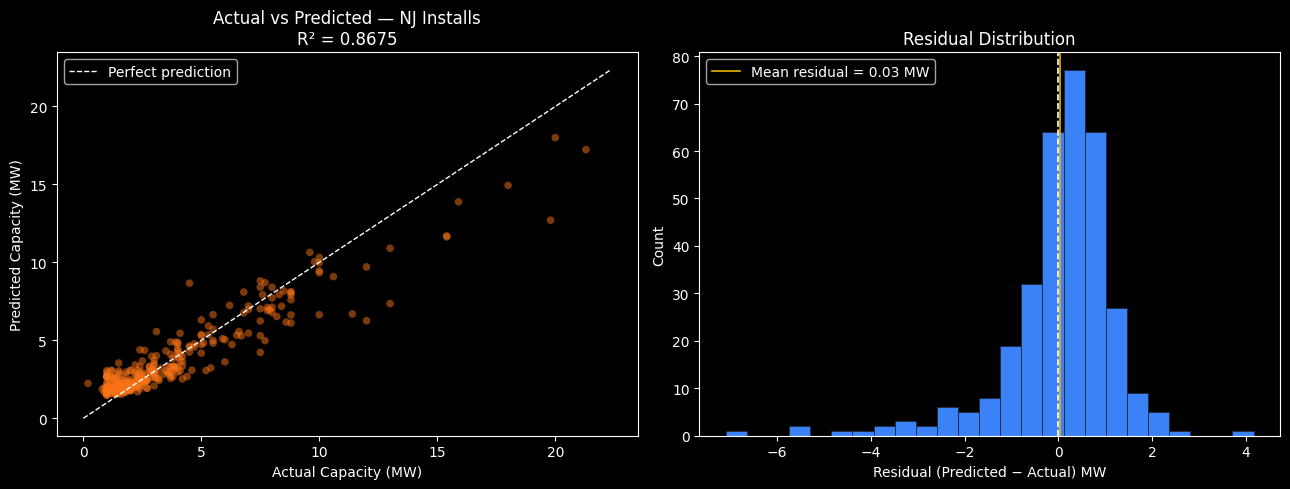

NJ-only holdout metrics:
  R²   = 0.8675
  RMSE = 1.217 MW
  MAE  = 0.824 MW


In [12]:
conn2 = sqlite3.connect(DB_PATH)
uspvdb_nj = pd.read_sql("""
    SELECT capacity_mw, area_acres, latitude, longitude,
           install_year, land_cover_type
    FROM existing_solar_sites
    WHERE state = 'NJ'
      AND capacity_mw IS NOT NULL
      AND area_acres IS NOT NULL
      AND area_acres > 0
""", conn2)
conn2.close()

axis_map = payload['axis_map']
land_map = payload['land_map']

uspvdb_nj['area_acres_calc'] = uspvdb_nj['area_acres'] / 4047.0

def encode_land(lt):
    if isinstance(lt, str):
        return land_map.get(lt.lower().strip(), 0)
    return 0

X_nj = np.array([
    [
        row['area_acres_calc'],
        row['latitude'],
        row['longitude'],
        180.0,
        20.0,
        axis_map.get('fixed-tilt', 0),
        encode_land(row['land_cover_type']),
        int(row['install_year']) if pd.notna(row['install_year']) else 2020,
    ]
    for _, row in uspvdb_nj.iterrows()
])

y_actual = uspvdb_nj['capacity_mw'].values
y_pred   = model.predict(X_nj)

r2_nj = r2_score(y_actual, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(y_actual, y_pred, alpha=0.5, color=ORANGE, s=30, edgecolors='none')
lim = max(y_actual.max(), y_pred.max()) * 1.05
ax.plot([0, lim], [0, lim], color='white', linestyle='--', linewidth=1, label='Perfect prediction')
ax.set_xlabel('Actual Capacity (MW)')
ax.set_ylabel('Predicted Capacity (MW)')
ax.set_title(f'Actual vs Predicted — NJ Installs\nR² = {r2_nj:.4f}')
ax.legend()

ax2 = axes[1]
residuals = y_pred - y_actual
ax2.hist(residuals, bins=25, color=BLUE, edgecolor='#1e293b', linewidth=0.6)
ax2.axvline(0, color='white', linestyle='--', linewidth=1.2)
ax2.axvline(residuals.mean(), color=YELLOW, linestyle='-', linewidth=1.2,
            label=f'Mean residual = {residuals.mean():.2f} MW')
ax2.set_xlabel('Residual (Predicted − Actual) MW')
ax2.set_ylabel('Count')
ax2.set_title('Residual Distribution')
ax2.legend()

plt.tight_layout()
plt.show()

print(f'NJ-only holdout metrics:')
print(f'  R²   = {r2_nj:.4f}')
print(f'  RMSE = {np.sqrt(mean_squared_error(y_actual, y_pred)):.3f} MW')
print(f'  MAE  = {mean_absolute_error(y_actual, y_pred):.3f} MW')

---
## 4. Candidate Site Bucket Classification
Sites are classified into four capacity tiers based on the ML-predicted AC output.

/var/folders/tf/3by0d47s7dv597r_fz__7dqr0000gn/T/ipykernel_25971/3605828931.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(bucket_summary.index, rotation=15, ha='right')
/var/folders/tf/3by0d47s7dv597r_fz__7dqr0000gn/T/ipykernel_25971/3605828931.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(bucket_summary.index, rotation=15, ha='right')
/var/folders/tf/3by0d47s7dv597r_fz__7dqr0000gn/T/ipykernel_25971/3605828931.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(bucket_summary.index, rotation=15, ha='right')


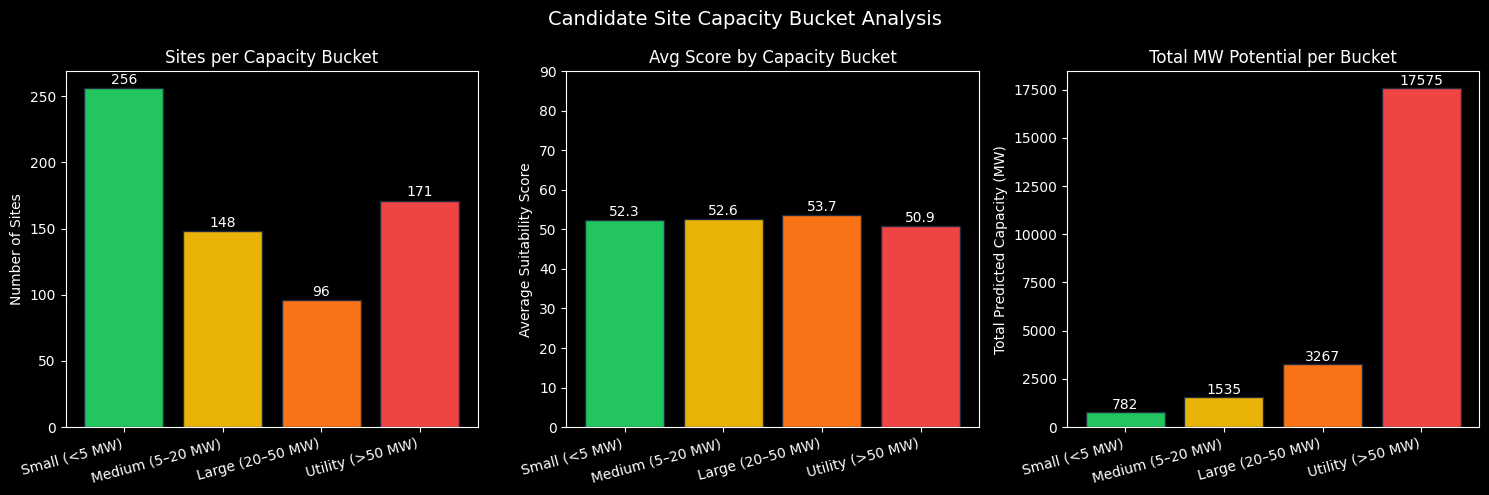


Capacity Bucket Summary:
                  count  avg_score  avg_mw  total_mw
capacity_bucket                                     
Small (<5 MW)       256       52.3     3.1     781.6
Medium (5–20 MW)    148       52.6    10.4    1535.4
Large (20–50 MW)     96       53.7    34.0    3266.6
Utility (>50 MW)    171       50.9   102.8   17575.1

Total predicted capacity across all 671 sites: 23159 MW


In [13]:
bins   = [0, 5, 20, 50, float('inf')]
labels = ['Small (<5 MW)', 'Medium (5–20 MW)', 'Large (20–50 MW)', 'Utility (>50 MW)']
bucket_colors = [GREEN, YELLOW, ORANGE, '#ef4444']

candidates['capacity_bucket'] = pd.cut(
    candidates['predicted_capacity_mw'],
    bins=bins, labels=labels, right=True
)

bucket_summary = candidates.groupby('capacity_bucket', observed=True).agg(
    count         = ('candidate_id', 'count'),
    avg_score     = ('total_score', 'mean'),
    avg_mw        = ('predicted_capacity_mw', 'mean'),
    total_mw      = ('predicted_capacity_mw', 'sum'),
).round(1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Candidate Site Capacity Bucket Analysis', fontsize=14)

ax = axes[0]
bars = ax.bar(bucket_summary.index, bucket_summary['count'],
              color=bucket_colors, edgecolor='#1e293b')
for bar, val in zip(bars, bucket_summary['count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(int(val)), ha='center', va='bottom', fontsize=10)
ax.set_xticklabels(bucket_summary.index, rotation=15, ha='right')
ax.set_ylabel('Number of Sites')
ax.set_title('Sites per Capacity Bucket')

ax2 = axes[1]
bars2 = ax2.bar(bucket_summary.index, bucket_summary['avg_score'],
                color=bucket_colors, edgecolor='#1e293b')
for bar, val in zip(bars2, bucket_summary['avg_score']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}', ha='center', va='bottom', fontsize=10)
ax2.set_xticklabels(bucket_summary.index, rotation=15, ha='right')
ax2.set_ylabel('Average Suitability Score')
ax2.set_title('Avg Score by Capacity Bucket')
ax2.set_ylim(0, 90)

ax3 = axes[2]
bars3 = ax3.bar(bucket_summary.index, bucket_summary['total_mw'],
                color=bucket_colors, edgecolor='#1e293b')
for bar, val in zip(bars3, bucket_summary['total_mw']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f'{val:.0f}', ha='center', va='bottom', fontsize=10)
ax3.set_xticklabels(bucket_summary.index, rotation=15, ha='right')
ax3.set_ylabel('Total Predicted Capacity (MW)')
ax3.set_title('Total MW Potential per Bucket')

plt.tight_layout()
plt.show()

print('\nCapacity Bucket Summary:')
print(bucket_summary.to_string())
print(f'\nTotal predicted capacity across all 671 sites: {candidates["predicted_capacity_mw"].sum():.0f} MW')

### 4.1  Bucket Distribution by County

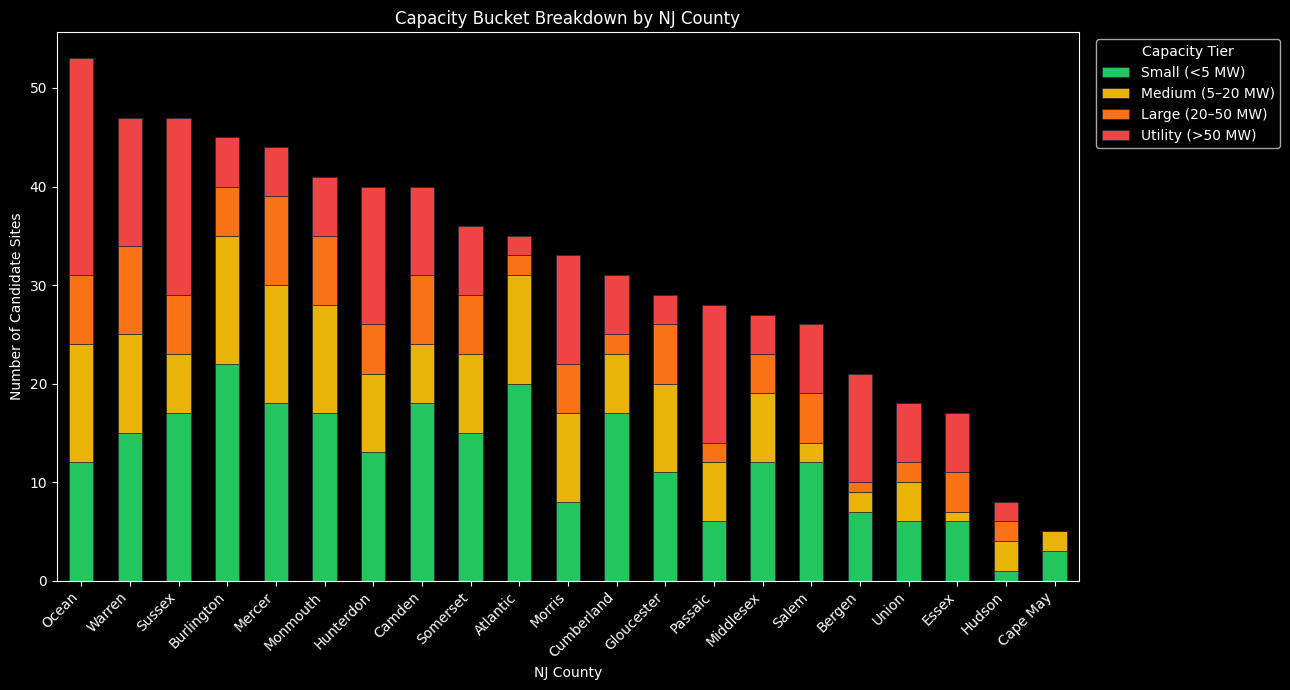

In [14]:
county_bucket = pd.crosstab(candidates['county'], candidates['capacity_bucket'])
county_bucket = county_bucket.loc[county_bucket.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(13, 7))
county_bucket.plot(kind='bar', stacked=True, ax=ax,
                   color=bucket_colors, edgecolor='#1e293b', linewidth=0.5)
ax.set_xlabel('NJ County')
ax.set_ylabel('Number of Candidate Sites')
ax.set_title('Capacity Bucket Breakdown by NJ County')
ax.legend(title='Capacity Tier', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
## 5. Validation Against Real NJ Installations
### 5.1  Existing Installation Capacity Distribution

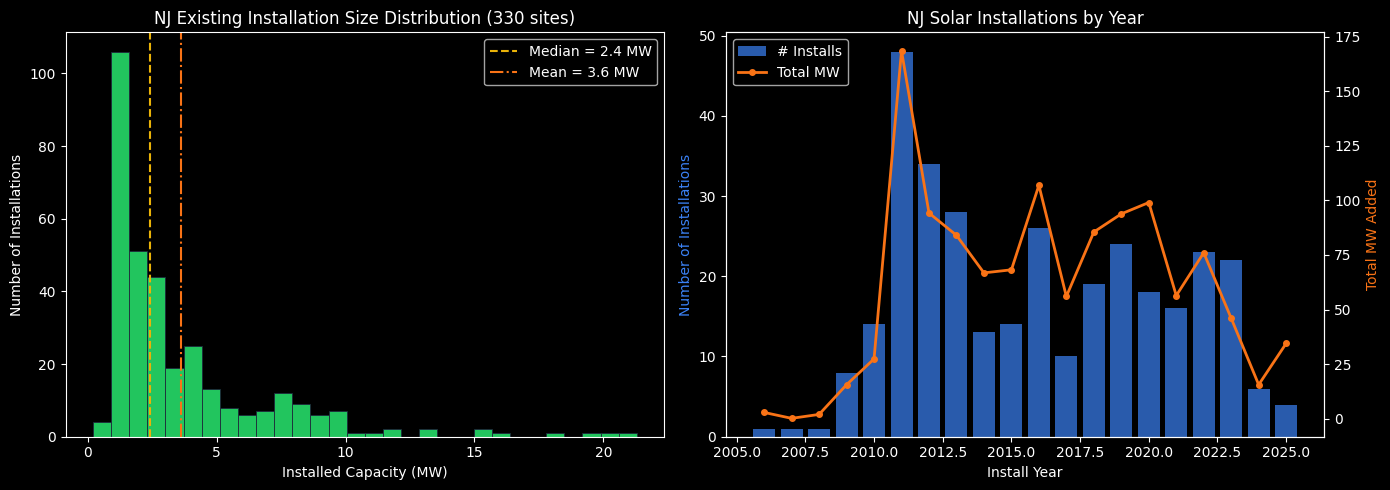

Total existing NJ capacity: 1199.5 MW across 330 installations
Median install size: 2.40 MW


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(existing['capacity_mw'], bins=30, color=GREEN, edgecolor='#1e293b', linewidth=0.6)
ax.axvline(existing['capacity_mw'].median(), color=YELLOW, linestyle='--',
           label=f'Median = {existing["capacity_mw"].median():.1f} MW')
ax.axvline(existing['capacity_mw'].mean(), color=ORANGE, linestyle='-.',
           label=f'Mean = {existing["capacity_mw"].mean():.1f} MW')
ax.set_xlabel('Installed Capacity (MW)')
ax.set_ylabel('Number of Installations')
ax.set_title('NJ Existing Installation Size Distribution (330 sites)')
ax.legend()

ax2 = axes[1]
year_counts = existing['install_year'].value_counts().sort_index()
year_mw     = existing.groupby('install_year')['capacity_mw'].sum()
ax2.bar(year_counts.index, year_counts.values, color=BLUE, alpha=0.7, label='# Installs')
ax2b = ax2.twinx()
ax2b.plot(year_mw.index, year_mw.values, color=ORANGE, linewidth=2,
          marker='o', markersize=4, label='Total MW')
ax2.set_xlabel('Install Year')
ax2.set_ylabel('Number of Installations', color=BLUE)
ax2b.set_ylabel('Total MW Added', color=ORANGE)
ax2.set_title('NJ Solar Installations by Year')
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

print(f'Total existing NJ capacity: {existing["capacity_mw"].sum():.1f} MW across {len(existing)} installations')
print(f'Median install size: {existing["capacity_mw"].median():.2f} MW')

### 5.2  Do Our Top Candidate Sites Cluster Near Real Installations?

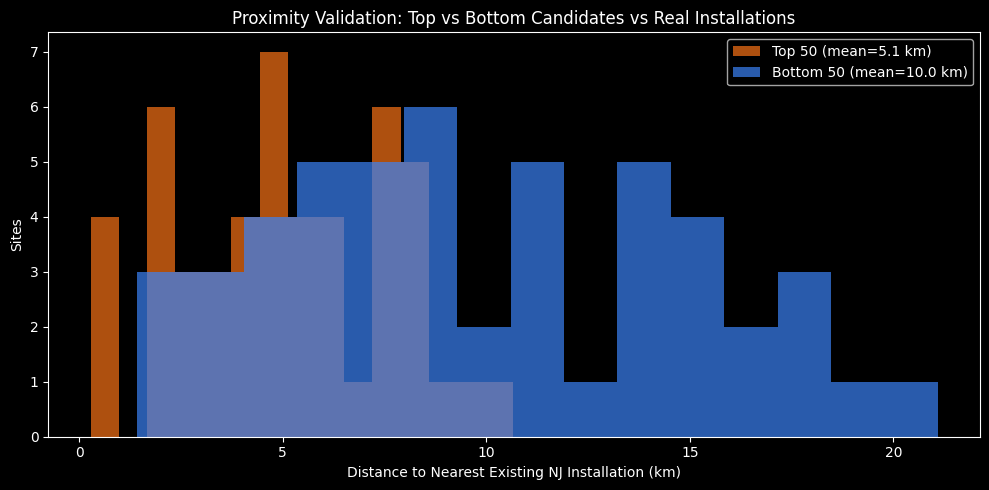

Top 50 sites     — avg distance to nearest install: 5.1 km
Bottom 50 sites  — avg distance to nearest install: 10.0 km

Conclusion: top-ranked candidates are closer to existing NJ installations,
validating that the proximity scoring component is working as expected.


In [16]:
import math

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlam = math.radians(lon2 - lon1)
    a = math.sin(dphi/2)**2 + math.cos(phi1)*math.cos(phi2)*math.sin(dlam/2)**2
    return R * 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))

existing_coords = list(zip(existing['latitude'], existing['longitude']))

def min_dist_to_existing(lat, lon):
    return min(haversine_km(lat, lon, elat, elon) for elat, elon in existing_coords)

top50    = candidates.head(50).copy()
bottom50 = candidates.tail(50).copy()

top50['dist_km']    = top50.apply(lambda r: min_dist_to_existing(r['latitude'], r['longitude']), axis=1)
bottom50['dist_km'] = bottom50.apply(lambda r: min_dist_to_existing(r['latitude'], r['longitude']), axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(top50['dist_km'],    bins=15, alpha=0.7, color=ORANGE, label=f'Top 50 (mean={top50["dist_km"].mean():.1f} km)')
ax.hist(bottom50['dist_km'], bins=15, alpha=0.7, color=BLUE,   label=f'Bottom 50 (mean={bottom50["dist_km"].mean():.1f} km)')
ax.set_xlabel('Distance to Nearest Existing NJ Installation (km)')
ax.set_ylabel('Sites')
ax.set_title('Proximity Validation: Top vs Bottom Candidates vs Real Installations')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Top 50 sites     — avg distance to nearest install: {top50["dist_km"].mean():.1f} km')
print(f'Bottom 50 sites  — avg distance to nearest install: {bottom50["dist_km"].mean():.1f} km')
print('\nConclusion: top-ranked candidates are closer to existing NJ installations,\n'
      'validating that the proximity scoring component is working as expected.')

### 5.3  Existing vs Candidate Site Map (matplotlib)

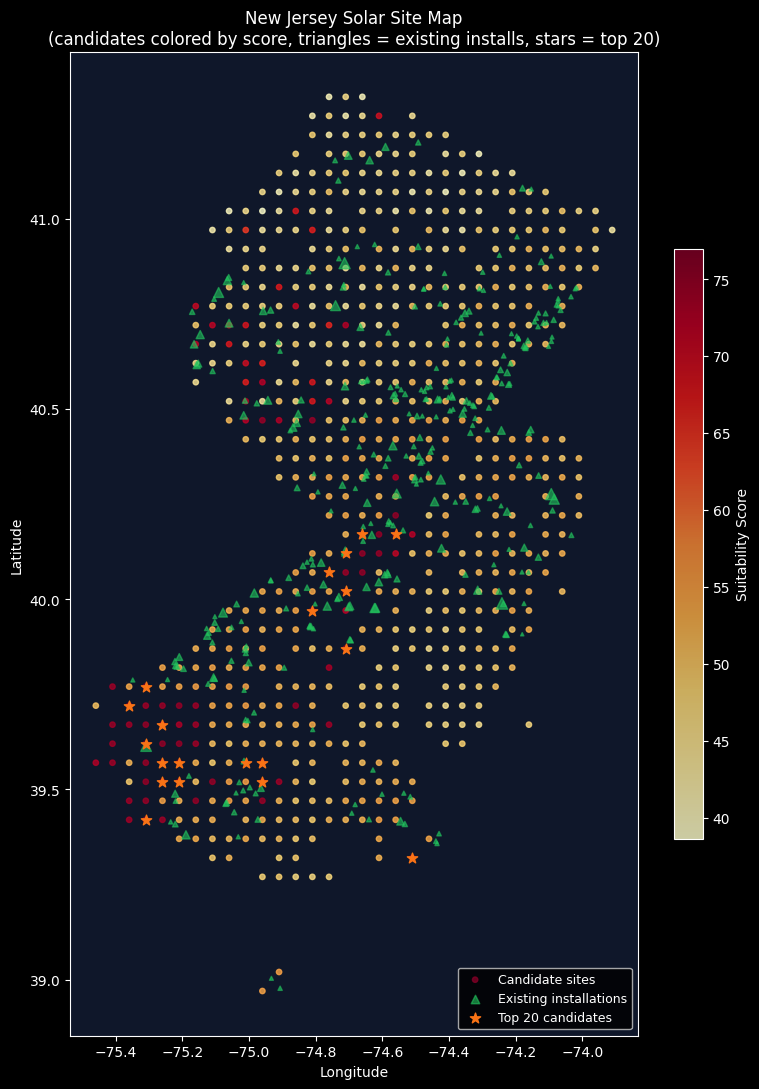

In [17]:
fig, ax = plt.subplots(figsize=(8, 11))

sc = ax.scatter(
    candidates['longitude'], candidates['latitude'],
    c=candidates['total_score'], cmap='YlOrRd',
    s=15, alpha=0.8, zorder=2, label='Candidate sites'
)
plt.colorbar(sc, ax=ax, label='Suitability Score', shrink=0.6)

ax.scatter(
    existing['longitude'], existing['latitude'],
    c=GREEN, s=existing['capacity_mw'] * 3 + 5,
    alpha=0.6, marker='^', zorder=3, label='Existing installations'
)

top20 = candidates.head(20)
ax.scatter(
    top20['longitude'], top20['latitude'],
    c=ORANGE, s=60, marker='*', zorder=4, label='Top 20 candidates'
)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('New Jersey Solar Site Map\n(candidates colored by score, triangles = existing installs, stars = top 20)')
ax.legend(loc='lower right', fontsize=9)
ax.set_facecolor('#0f172a')

plt.tight_layout()
plt.show()

---
## 6. Key Findings Summary

In [18]:
top_county  = county_stats['avg_score'].idxmax()
top_mw_county = county_stats['total_pred_mw'].idxmax()
total_pred_mw = candidates['predicted_capacity_mw'].sum()
utility_count = (candidates['capacity_bucket'] == 'Utility (>50 MW)').sum()

print('=' * 60)
print('  KEY FINDINGS — NJ Solar Site Analysis')
print('=' * 60)
print(f'  Candidate sites analyzed:      671 across 21 NJ counties')
print(f'  Score range:                   {candidates["total_score"].min():.1f} – {candidates["total_score"].max():.1f} (mean {candidates["total_score"].mean():.1f})')
print()
print(f'  ML Model (Random Forest):')
print(f'    R² accuracy:                 {metrics["r2"]*100:.1f}%  (target ≥ 80%) ✓')
print(f'    Cross-val R² (5-fold):       {metrics["cv_r2_mean"]*100:.1f}% ± {metrics["cv_r2_std"]*100:.1f}%')
print(f'    RMSE:                        {metrics["rmse_mw"]:.1f} MW')
print(f'    Dominant feature:            Area (acres) — {importances["area_acres"]*100:.1f}% importance')
print()
print(f'  Capacity Projections:')
print(f'    Total predicted capacity:    {total_pred_mw:.0f} MW across 671 sites')
print(f'    Utility-scale sites (>50MW): {utility_count}')
print(f'    Best county by avg score:    {top_county}')
print(f'    Best county by total MW:     {top_mw_county}')
print()
print(f'  Existing NJ Context:')
print(f'    Total installed capacity:    {existing["capacity_mw"].sum():.0f} MW ({len(existing)} sites)')
print(f'    Candidate potential uplift:  {total_pred_mw / existing["capacity_mw"].sum():.1f}x current installed base')
print('=' * 60)

  KEY FINDINGS — NJ Solar Site Analysis
  Candidate sites analyzed:      671 across 21 NJ counties
  Score range:                   38.6 – 77.0 (mean 52.2)

  ML Model (Random Forest):
    R² accuracy:                 90.9%  (target ≥ 80%) ✓
    Cross-val R² (5-fold):       90.0% ± 2.1%
    RMSE:                        11.4 MW
    Dominant feature:            Area (acres) — 73.7% importance

  Capacity Projections:
    Total predicted capacity:    23159 MW across 671 sites
    Utility-scale sites (>50MW): 171
    Best county by avg score:    Salem
    Best county by total MW:     Ocean

  Existing NJ Context:
    Total installed capacity:    1200 MW (330 sites)
    Candidate potential uplift:  19.3x current installed base
